In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

In [ ]:
## Exploración, Preprocesamiento, Entrenamiento y Evaluación
En las celdas siguientes realizaremos:

- Exploración rápida del dataset (columnas, valores faltantes, distribución de la variable objetivo).
- Muestreo estratificado/selección para trabajar con un subconjunto razonable (el dataset es muy grande).
- Preprocesamiento: selección de características numéricas, codificación de categóricas y escalado.
- Entrenamiento de un modelo de regresión logística y evaluación con métricas y curvas ROC.

# Paso 1 — Exploración inicial (EDA)
En esta celda revisaremos dimensiones, tipos, nulos y distribución de la variable objetivo.

In [6]:
# Paso 1: Exploración inicial
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

print("Shape del dataset:", df.shape)
print('\nTipos y valores nulos:')
print(df.info())
print('\nValores nulos por columna:\n', df.isnull().sum())

# Detectar nombre de la columna objetivo (contiene 'fraud')
possible_targets = [c for c in df.columns if 'fraud' in c.lower()]
if len(possible_targets) == 0:
    raise ValueError("No se encontró una columna objetivo que contenga 'fraud' en su nombre. Revise el dataset.")

target = possible_targets[0]
print(f"\nUsando '{target}' como variable objetivo")

# Distribución de clases
vc = df[target].value_counts()
print('\nDistribución de la variable objetivo:\n', vc)
print('\nPorcentajes:\n', df[target].value_counts(normalize=True) * 100)

Shape del dataset: (6362620, 11)

Tipos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Valores nulos por columna:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Usando 'isFraud' como variable objetivo

Distribución de la variable objetivo:
 isFraud
0    6354407
1       8213
Name: c

# Paso 2 — Muestreo para manejo de tamaño
Vamos a crear un subconjunto manejable: conservar todas las fraudes y muestrear no-fraudes.

In [7]:
# Paso 2: Muestreo
n_frauds = int(df[target].sum())
print(f"Número de transacciones fraudulentas: {n_frauds}")

MAX_NON_FRAUD = 200_000
if len(df) <= 300_000:
    sampled = df.copy()
    print("Dataset pequeño: usando todo")
else:
    if n_frauds == 0:
        raise ValueError('No se encontraron casos con la clase fraudulenta = 1 en el dataset.')
    nonfraud_sample_size = min(MAX_NON_FRAUD, max(n_frauds * 10, 50_000))
    sampled = pd.concat([
        df[df[target] == 1],
        df[df[target] == 0].sample(n=nonfraud_sample_size, random_state=42)
    ])
    sampled = sampled.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Subconjunto creado con {len(sampled)} filas: {sampled[target].sum()} fraudes y {len(sampled)-sampled[target].sum()} no-fraudes")

# Guardar una copia pequeña para inspección rápida
sampled.head()

Número de transacciones fraudulentas: 8213
Subconjunto creado con 90343 filas: 8213 fraudes y 82130 no-fraudes
Subconjunto creado con 90343 filas: 8213 fraudes y 82130 no-fraudes


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,137,CASH_IN,125283.17,C1931461578,3114832.07,3240115.24,C1280154266,619337.07,494053.90,0,0
1,352,CASH_OUT,472302.80,C1312658751,65541.00,0.00,C1566914608,270001.32,742304.12,0,0
2,280,CASH_IN,37885.22,C1264362084,668.00,38553.22,C768696846,15678.68,0.00,0,0
3,19,PAYMENT,15962.23,C687637039,0.00,0.00,M881194713,0.00,0.00,0,0
4,299,CASH_OUT,79489.63,C2025516895,11194.00,0.00,C722650066,478920.95,558410.58,0,0


# Paso 3 — Selección y preprocesamiento de features
Separar numéricas y categóricas, codificar categóricas de baja cardinalidad y preparar X, y.

In [8]:
# Paso 3: Preprocesamiento
numeric_cols = sampled.select_dtypes(include=[np.number]).columns.tolist()
if target in numeric_cols:
    numeric_cols.remove(target)
categorical_cols = sampled.select_dtypes(exclude=[np.number]).columns.tolist()

print('\nColumnas numéricas (ejemplo):', numeric_cols[:10])
print('\nColumnas categóricas (ejemplo):', categorical_cols[:10])

# Preparar X e y
y = sampled[target].values
X_num = sampled[numeric_cols].copy()

if len(categorical_cols) > 0:
    low_card_cols = [c for c in categorical_cols if sampled[c].nunique() <= 30]
    X_cat = pd.get_dummies(sampled[low_card_cols].astype(str), drop_first=True)
    print(f"Codificadas {len(low_card_cols)} columnas categóricas -> {X_cat.shape[1]} dummies")
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
else:
    X = X_num

print('\nDimensiones finales de X:', X.shape)
feature_names = X.columns.tolist()


Columnas numéricas (ejemplo): ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']

Columnas categóricas (ejemplo): ['type', 'nameOrig', 'nameDest']
Codificadas 1 columnas categóricas -> 4 dummies

Dimensiones finales de X: (90343, 11)


# Paso 4 — División train/test y escalado
Hacer split estratificado y escalar características.

In [9]:
# Paso 4: Train/Test y escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (72274, 11) Test: (18069, 11)


# Paso 5 — Entrenamiento del modelo
Entrenar regresión logística con class_weight='balanced' para manejar el desbalance.

In [10]:
# Paso 5: Entrenamiento
model = LogisticRegression(solver='saga', penalty='l2', class_weight='balanced', max_iter=1000, n_jobs=-1, random_state=42)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

/Users/pablodanielvelazquezsalgado/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Paso 6 — Evaluación
Reporte de clasificación, matriz de confusión, ROC AUC y top features.


Reporte de clasificación (conjunto de test):
              precision    recall  f1-score   support

           0     0.9929    0.9427    0.9671     16426
           1     0.6195    0.9324    0.7444      1643

    accuracy                         0.9418     18069
   macro avg     0.8062    0.9376    0.8558     18069
weighted avg     0.9589    0.9418    0.9469     18069



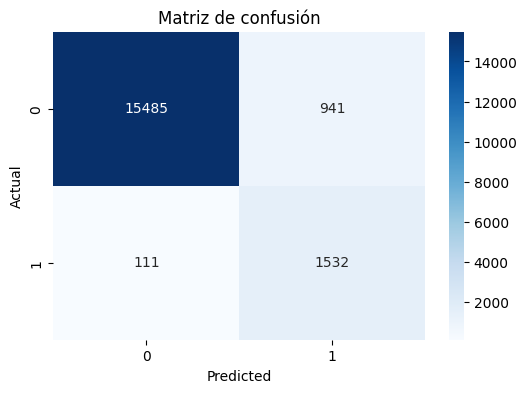

ROC AUC: 0.9864


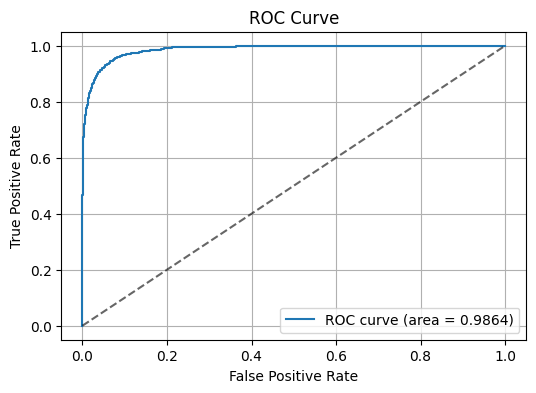


Top 20 features por magnitud de coeficiente:
oldbalanceOrg     27.785963
newbalanceOrig    26.082090
amount             4.588164
type_CASH_OUT      4.304620
newbalanceDest     4.005410
type_TRANSFER      3.461077
oldbalanceDest     3.443501
isFlaggedFraud     0.615607
step               0.427372
type_PAYMENT       0.135063
type_DEBIT         0.024010
dtype: float64


/var/folders/dm/cmjxr8d51_gfdz2rcb312pr00000gn/T/ipykernel_9581/1270935180.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs_abs.values, y=coefs_abs.index, palette='viridis')


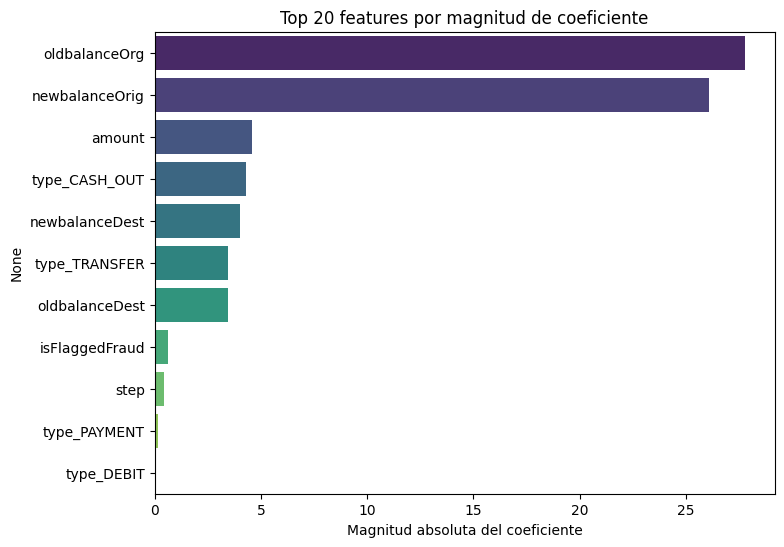

In [11]:
# Paso 6: Evaluación
print('\nReporte de clasificación (conjunto de test):')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de confusión')
plt.show()

auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (area = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

coefs = pd.Series(model.coef_.ravel(), index=feature_names)
coefs_abs = coefs.abs().sort_values(ascending=False).head(20)
print('\nTop 20 features por magnitud de coeficiente:')
print(coefs_abs)

plt.figure(figsize=(8,6))
sns.barplot(x=coefs_abs.values, y=coefs_abs.index, palette='viridis')
plt.title('Top 20 features por magnitud de coeficiente')
plt.xlabel('Magnitud absoluta del coeficiente')
plt.show()
